In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("praveengovi/emotions-dataset-for-nlp")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'emotions-dataset-for-nlp' dataset.
Path to dataset files: /kaggle/input/emotions-dataset-for-nlp


In [8]:
import os

print(os.listdir("/kaggle/input/emotions-dataset-for-nlp"))


['val.txt', 'test.txt', 'train.txt']


In [9]:
import pandas as pd

train_df = pd.read_csv('/kaggle/input/emotions-dataset-for-nlp/train.txt', sep=';', header=None, names=['text', 'label'])
val_df = pd.read_csv('/kaggle/input/emotions-dataset-for-nlp/val.txt', sep=';', header=None, names=['text', 'label'])
test_df = pd.read_csv('/kaggle/input/emotions-dataset-for-nlp/test.txt', sep=';', header=None, names=['text', 'label'])

#Exploring Data

In [10]:
train_df.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [11]:
print(f"Train set shape:      {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"Test set shape:       {test_df.shape}")

Train set shape:      (16000, 2)
Validation set shape: (2000, 2)
Test set shape:       (2000, 2)


In [12]:
print("Number of duplicate rows in each split:")
print(f"Train:      {train_df.duplicated().sum()}")
print(f"Validation: {val_df.duplicated().sum()}")
print(f"Test:       {test_df.duplicated().sum()}")

Number of duplicate rows in each split:
Train:      1
Validation: 0
Test:       0


In [13]:
train_df.drop_duplicates(inplace=True)

#Text Duplicates with Conflicting Labels

In [14]:
duplicates_tweet_id = train_df[train_df['text'].duplicated(keep=False)]
duplicates_tweet_id_sorted = duplicates_tweet_id.sort_values(by='text')
duplicates_tweet_id_sorted

,text,label
3508,i am not amazing or great at photography but i...,joy
8246,i am not amazing or great at photography but i...,love
15705,i began to feel accepted by gaia on her own terms,joy
5277,i began to feel accepted by gaia on her own terms,love
15572,i bet taylor swift basks in the knowledge that...,anger
8804,i bet taylor swift basks in the knowledge that...,fear
11013,i cant escape the tears of sadness and just tr...,love
12892,i cant escape the tears of sadness and just tr...,joy
13653,i could feel myself hit this strange foggy wall,fear
14314,i could feel myself hit this strange foggy wall,surprise


In [15]:
conflicts = duplicates_tweet_id_sorted.groupby("text")["label"].nunique()
print(conflicts[conflicts > 1])

text
i am not amazing or great at photography but i feel passionate about it                                                                                                                    2
i began to feel accepted by gaia on her own terms                                                                                                                                          2
i bet taylor swift basks in the knowledge that the boys she writes songs about probably feel tortured                                                                                      2
i cant escape the tears of sadness and just true grief i feel at the loss of my sweet friend and sister                                                                                    2
i could feel myself hit this strange foggy wall                                                                                                                                            2
i feel a remembrance of the strange by justin aryi

In [16]:
train_df = train_df.drop_duplicates(subset="text")

In [17]:
train_df = train_df.groupby("text").first().reset_index()

In [18]:
duplicates_tweet_id = train_df[train_df['text'].duplicated(keep=False)]
duplicates_tweet_id_sorted = duplicates_tweet_id.sort_values(by='text')
duplicates_tweet_id_sorted

,text,label


In [19]:
duplicates_tweet_id = val_df[val_df['text'].duplicated(keep=False)]
duplicates_tweet_id_sorted = duplicates_tweet_id.sort_values(by='text')
duplicates_tweet_id_sorted

,text,label
774,i feel so tortured by it,fear
1993,i feel so tortured by it,anger
300,i have had several new members tell me how com...,love
603,i have had several new members tell me how com...,joy


In [20]:
conflicts = duplicates_tweet_id_sorted.groupby("text")["label"].nunique()
print(conflicts[conflicts > 1])

text
i feel so tortured by it                                                                                                                         2
i have had several new members tell me how comfortable they feel with how accepted they are by the existing members and that is great to hear    2
Name: label, dtype: int64


In [21]:
val_df = val_df.drop_duplicates(subset="text")

In [22]:
val_df = val_df.groupby("text").first().reset_index()

In [23]:
duplicates_tweet_id = val_df[val_df['text'].duplicated(keep=False)]
duplicates_tweet_id_sorted = duplicates_tweet_id.sort_values(by='text')
duplicates_tweet_id_sorted

,text,label


In [24]:
duplicates_content = test_df[test_df['text'].duplicated(keep=False)]
duplicates_content_sorted = duplicates_content.sort_values(by='text')
duplicates_content_sorted

,text,label


#Checking Nulls

In [25]:
print("🔍 Null values in Train set:")
print(train_df.isnull().sum())

print("\n🔍 Null values in Validation set:")
print(val_df.isnull().sum())

print("\n🔍 Null values in Test set:")
print(test_df.isnull().sum())


🔍 Null values in Train set:
text     0
label    0
dtype: int64

🔍 Null values in Validation set:
text     0
label    0
dtype: int64

🔍 Null values in Test set:
text     0
label    0
dtype: int64


#Preprocessing

In [26]:
print(f"Train set shape:      {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"Test set shape:       {test_df.shape}")

Train set shape:      (15969, 2)
Validation set shape: (1998, 2)
Test set shape:       (2000, 2)


In [27]:
train_df['text']

,text
0,a boyfriend with whom i split up with came ove...
1,a certain friend tried to push me off a seat i...
2,a father of children killed in an accident
3,a few monthe ago
4,a friend of mine suggested that i become a fil...
...,...
15964,when there was a possibility of getting on bet...
15965,when they changed my office to another room wi...
15966,when they phoned me from greatbritain to tell ...
15967,when we stayed in vienna with our class


In [28]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.5 MB/s eta 0:00:00


In [29]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions  # library for expanding contractions

# Download resources if not already
nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # 0. Expand contractions (I'm -> I am, don't -> do not)
    text = contractions.fix(text)

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove mentions (@user)
    text = re.sub(r"@\w+", "", text)

    # 3. Remove hashtags (#happy -> happy)
    text = re.sub(r"#", "", text)

    # 4. Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # 5. Remove numbers
    text = re.sub(r"\d+", "", text)

    # 6. Remove punctuation & special characters (keep only letters & spaces)
    text = re.sub(r"[^a-z\s]", "", text)

    # 7. Tokenize, remove stopwords, and lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]

    # 8. Strip extra spaces
    text = " ".join(tokens)

    return text


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [30]:
train_df['Cleaned_Text']=train_df['text'].apply(preprocess)
val_df['Cleaned_Text']=val_df['text'].apply(preprocess)
test_df['Cleaned_Text']=test_df['text'].apply(preprocess)

In [31]:
train_df['label'].value_counts()

,count
label,
joy,5350
sadness,4664
anger,2155
fear,1933
love,1299
surprise,568


#Evaluation

In [32]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# =====================
# 1. Baseline Model
# =====================
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=200, random_state=42))
])

baseline_model.fit(train_df['Cleaned_Text'], train_df["label"])

# Evaluate on test set
y_pred_baseline = baseline_model.predict(test_df["Cleaned_Text"])
print("=== Baseline Model ===")
print(classification_report(test_df["label"], y_pred_baseline))

# Save baseline model
joblib.dump(baseline_model, "emotion_model_baseline.pkl")
print("✅ Baseline model saved as emotion_model_baseline.pkl\n")


# =====================
# 2. Balanced Model
# =====================
balanced_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=200, class_weight="balanced", random_state=42))
])

balanced_model.fit(train_df["Cleaned_Text"], train_df["label"])

# Evaluate on test set
y_pred_balanced = balanced_model.predict(test_df["Cleaned_Text"])
print("=== Balanced Model ===")
print(classification_report(test_df["label"], y_pred_balanced))

# Save balanced model
joblib.dump(balanced_model, "emotion_model_balanced.pkl")
print("✅ Balanced model saved as emotion_model_balanced.pkl")


=== Baseline Model ===
              precision    recall  f1-score   support

       anger       0.90      0.85      0.87       275
        fear       0.90      0.84      0.87       224
         joy       0.87      0.96      0.91       695
        love       0.84      0.67      0.74       159
     sadness       0.91      0.94      0.93       581
    surprise       0.87      0.52      0.65        66

    accuracy                           0.89      2000
   macro avg       0.88      0.79      0.83      2000
weighted avg       0.89      0.89      0.88      2000

✅ Baseline model saved as emotion_model_baseline.pkl

=== Balanced Model ===
              precision    recall  f1-score   support

       anger       0.87      0.92      0.90       275
        fear       0.89      0.84      0.86       224
         joy       0.95      0.89      0.92       695
        love       0.70      0.94      0.80       159
     sadness       0.96      0.90      0.93       581
    surprise       0.65      0.8

=== Evaluation on Test Data ===
              precision    recall  f1-score   support

       anger       0.87      0.92      0.90       275
        fear       0.89      0.84      0.86       224
         joy       0.95      0.89      0.92       695
        love       0.70      0.94      0.80       159
     sadness       0.96      0.90      0.93       581
    surprise       0.65      0.88      0.75        66

    accuracy                           0.90      2000
   macro avg       0.84      0.89      0.86      2000
weighted avg       0.91      0.90      0.90      2000



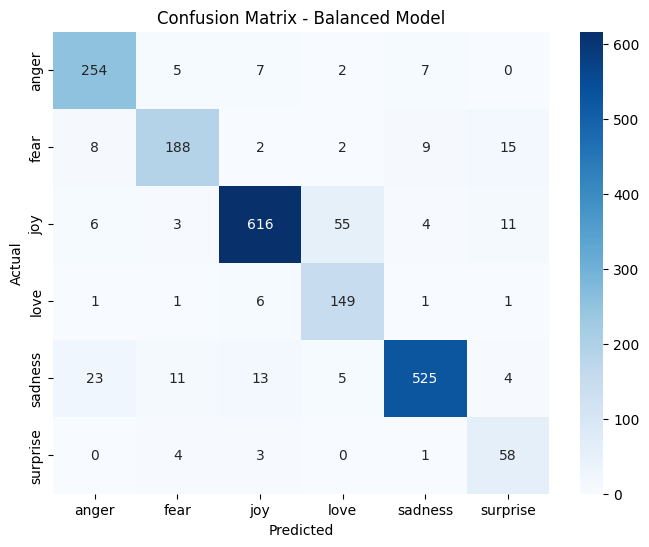

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the model if needed
balanced_model = joblib.load("emotion_model_balanced.pkl")

# Test data
X_test = test_df["Cleaned_Text"]
y_test = test_df["label"]

# Predictions
y_pred = balanced_model.predict(X_test)

# Evaluation Report
print("=== Evaluation on Test Data ===")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=balanced_model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=balanced_model.classes_, yticklabels=balanced_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Balanced Model")
plt.show()


In [34]:
samples = [
    "I am so happy today!",
    "I feel really scared walking alone at night.",
    "I miss my best friend so much.",
    "You make me so angry!",
    "Wow, I didn’t expect that to happen!"
]

preds = balanced_model.predict(samples)
for text, label in zip(samples, preds):
    print(f"{text} --> {label}")


I am so happy today! --> joy
I feel really scared walking alone at night. --> fear
I miss my best friend so much. --> sadness
You make me so angry! --> anger
Wow, I didn’t expect that to happen! --> joy


#Integrating Speech-to-Text

In [34]:
pip install speechrecognition pyaudio scikit-learn nltk


In [35]:
%pip install gradio


In [37]:
pip install speechrecognition

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 15.2 MB/s eta 0:00:00


In [38]:
import joblib
import speech_recognition as sr
import gradio as gr

# Load trained model
model = joblib.load("emotion_model_balanced.pkl")
print("✅ Model loaded successfully")

def predict_emotion(audio):
    recognizer = sr.Recognizer()
    try:
        with sr.AudioFile(audio) as source:
            recorded_audio = recognizer.record(source)
        text = recognizer.recognize_google(recorded_audio)
        prediction = model.predict([text])[0]
        return f"📝 Recognized Text: {text}\n➡️ Predicted Emotion: {prediction}"
    except sr.UnknownValueError:
        return "❌ Could not understand audio"
    except sr.RequestError:
        return "⚠️ Speech Recognition service not available"

# Gradio interface with bigger output box
iface = gr.Interface(
    fn=predict_emotion,
    inputs=gr.Audio(type="filepath"),  # mic recording works automatically in browser
    outputs=gr.Textbox(lines=10, placeholder="Prediction will appear here...", interactive=False),
    title="🎤 Real-Time Speech Emotion Recognition",
    description="Speak into your microphone and detect the emotion in your speech."
)

iface.launch(inbrowser=True)  # open directly in browser


✅ Model loaded successfully
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0f8d9c7e58b4e89465.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [39]:
pip install gradio speechrecognition joblib google-genai


In [40]:
pip install google-genai


In [56]:
import os
import joblib
import speech_recognition as sr
import gradio as gr
from google import genai

# ===============================
# 1. Set API key for Gemini
# ===============================
from google.colab import userdata
api_key=userdata.get('GOOGLE_API_KEY_1')

client = genai.Client(api_key=api_key)

In [57]:
# ===============================
# 2. Load your balanced ML model
# ===============================
balanced_model = joblib.load("emotion_model_balanced.pkl")
print("✅ Balanced ML model loaded successfully")

✅ Balanced ML model loaded successfully


In [58]:


# ===============================
# 3. Gemini LLM wrapper
# ===============================
class GeminiLLM:
    def __init__(self, client, model_name="gemini-2.5-pro"):
        self.client = client
        self.model_name = model_name

    def _call(self, text: str) -> str:
        # General-purpose prompt for classifying emotion
        prompt = (
            f"Classify the emotion of the following text: '{text}'. "
            "Choose one of: happy, sad, angry, neutral, surprised. "
            "Return only the emotion word."
        )
        response = self.client.models.generate_content(
            model=self.model_name,
            contents=prompt
        )
        return response.text.strip()

# Initialize Gemini LLM wrapper
llm = GeminiLLM(client)

In [59]:
# ===============================
# 4. Emotion prediction function
# ===============================
def predict_emotion(audio, threshold=0.7):
    recognizer = sr.Recognizer()
    try:
        # Convert audio to text
        with sr.AudioFile(audio) as source:
            recorded_audio = recognizer.record(source)
        text = recognizer.recognize_google(recorded_audio)

        # ML model prediction
        probs = balanced_model.predict_proba([text])[0]
        pred_index = probs.argmax()
        pred_class = balanced_model.classes_[pred_index]
        confidence = probs[pred_index]

        # Threshold check: fallback to Gemini if low confidence
        if confidence >= threshold:
            predicted_emotion = pred_class
            fallback_used = False
        else:
            predicted_emotion = llm._call(text)
            fallback_used = True

        # Build output string
        output = (
            f"📝 Recognized Text: {text}\n"
            f"➡️ Predicted Emotion: {predicted_emotion} (Confidence: {confidence:.2f})"
        )
        if fallback_used:
            output += " ⚠️ Low confidence, Gemini LLM fallback used"

        return output

    except sr.UnknownValueError:
        return "❌ Could not understand audio"
    except sr.RequestError:
        return "⚠️ Speech Recognition service not available"


In [60]:
# ===============================
# 5. Gradio interface
# ===============================
iface = gr.Interface(
    fn=predict_emotion,
    inputs=gr.Audio(type="filepath"),  # Microphone input works in browser
    outputs=gr.Textbox(
        lines=12,
        placeholder="Prediction will appear here...",
        interactive=False
    ),
    title="🎤 Real-Time Speech Emotion Recognition",
    description=(
        "Speak into your microphone to detect the emotion in your speech.\n"
        "Low-confidence predictions fallback to Gemini LLM."
    ),
)

# Launch the app
iface.launch(inbrowser=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5e95eb158873876e47.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
